In [2]:
print("""
@File         : implementing_forward_and_backward_fill.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-26 21:55:09
@Email        : cuixuanstephen@gmail.com
@Description  : 前向填充和后向填充
""")


@File         : implementing_forward_and_backward_fill.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-26 21:55:09
@Email        : cuixuanstephen@gmail.com
@Description  : 前向填充和后向填充



In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('../../DATA/air_passengers.csv', 
                 parse_dates=['ds'], 
                 index_col='ds')

df.head()

,y
ds,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


In [8]:
df.isnull().mean()

y    0.256944
dtype: float64

Text(0.5, 1.0, 'Air passengers')

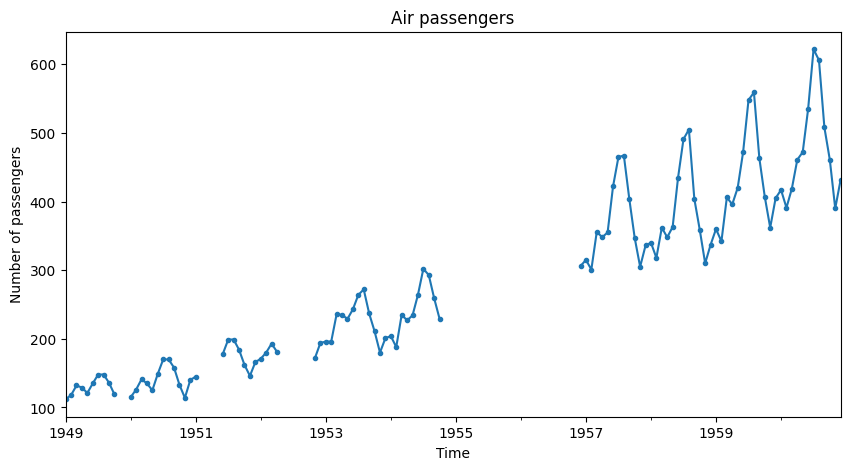

In [11]:
ax = df.plot(marker='.', figsize=(10, 5), legend=None)
ax.set_xlabel('Time')
ax.set_ylabel('Number of passengers')
ax.set_title('Air passengers')

`df_imputed[df.isnull()]` 这段代码有意思，可以避免线图问题，直接使用点来绘图，没选到的数据为 `NAN`。

Text(0.5, 1.0, 'Air passengers')

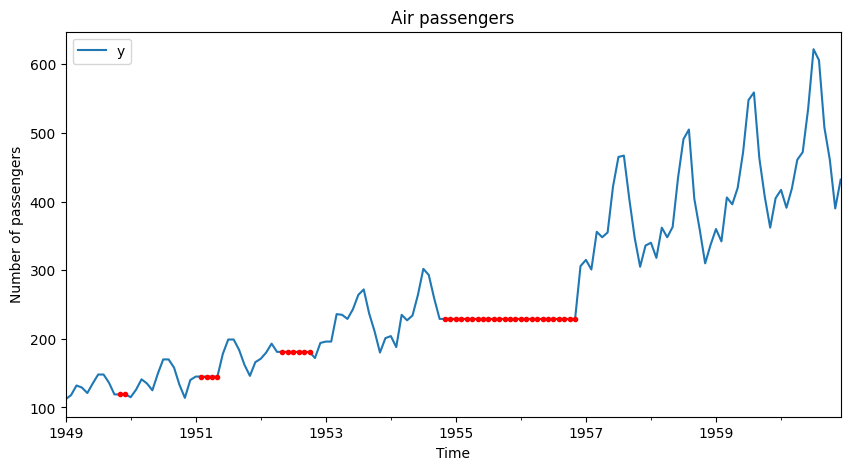

In [ ]:
df_imputed = df.ffill()

ax = df_imputed.plot(linestyle='-', figsize=(10, 5))
df_imputed[df.isnull()].plot(ax=ax, legend=None, marker='.', color='r')
ax.set_xlabel('Time')
ax.set_ylabel('Number of passengers')
ax.set_title('Air passengers Forward Fill')

Text(0.5, 1.0, 'Air passengers Backward Fill')

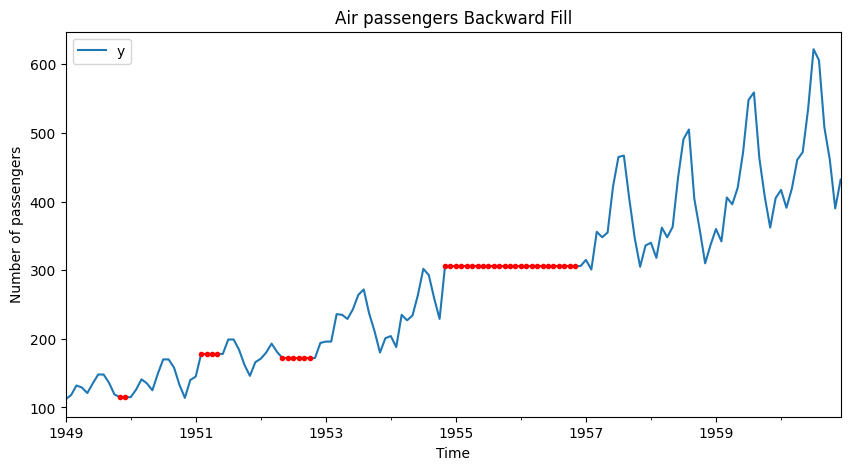

In [26]:
df_imputed = df.bfill()
ax = df_imputed.plot(linestyle='-', figsize=(10, 5))
df_imputed[df.isnull()].plot(ax=ax, legend=None, marker='.', color='r')
ax.set_xlabel('Time')
ax.set_ylabel('Number of passengers')
ax.set_title('Air passengers Backward Fill')

默认情况下，`ffill()` 和 `bfill()` 会插补有效观测值之间的所有值。我们可以通过设置限制将插补限制为任何间隔内的最大数据点数，在两种方法中均使用 `limit` 参数。例如，`ffill(limit=10)` 将仅替换任何间隙中的前 10 个数据点。